#**Emotion Classification with RNNs, LSTMs & GRUs**

Classifying text into 6 emotions (**sadness, joy, love, anger, fear, surprise**) by comparing plain recurrent models before building an **Advanced Bidirectional GRU**.

###**1. Import Libraries**
Import TensorFlow/Keras, HuggingFace Datasets, and evaluation tools.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#dataset load krwane mai help karegi
from datasets import load_dataset

###**2. Load Dataset**
Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [2]:
emotion_dataset = load_dataset("dair-ai/emotion")
train_text      = emotion_dataset["train"]["text"]
train_label     = emotion_dataset["train"]["label"]

test_text       = emotion_dataset["test"]["text"]
test_label      = emotion_dataset["test"]["label"]

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_names = emotion_dataset["train"].features["label"].names

In [4]:
df_train = pd.DataFrame(
    {
        'text': train_text,
        'label': [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text': test_text,
        'label': [label_names[i] for i in test_label]
    }
)

In [5]:
df_train.isnull().sum()

,0
text,0
label,0


###**3. Exploratory Data Analysis (EDA)**
Visualize class distribution across the 6 emotion labels.

In [6]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

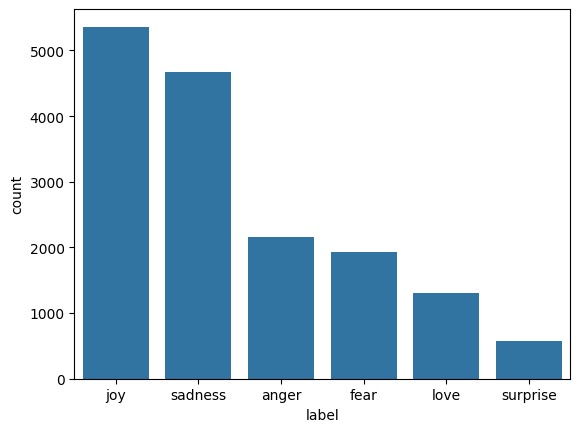

In [7]:
sns.countplot(x = 'label', data = df_train, order=df_train['label'].value_counts().index)

In [8]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


###**4. Data Preprocessing - Using NLP**
Tokenize text, pad sequences to max length 50, and convert labels to NumPy arrays.

In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_train['text'])

train_sequences = tokenizer.texts_to_sequences(df_train['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequences = pad_sequences(train_sequences, maxlen=50, padding='post', truncating='post')
padded_test_sequences = pad_sequences(test_sequences, maxlen=50, padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length : {padded_train_sequences.shape[1]}")


Vocabulary size: 15213
Max Sentence Length : 50


###**5. Shared Training Utilities**
Compute balanced class weights to handle dataset skew and setup early stopping.

In [10]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

###**6. Phase 1 — Plain Foundational Models**
Train plain (non-bidirectional) Simple RNN, Standard LSTM, and Standard GRU models.

###**6.1 Model 1 — Simple RNN**
Plain unrolled Recurrent Neural Network.

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [15]:
model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = model.evaluate(padded_test_sequences, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.1334 - loss: 1.8122 - val_accuracy: 0.1355 - val_loss: 1.8049
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1345 - loss: 1.8073 - val_accuracy: 0.2845 - val_loss: 1.7721
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1357 - loss: 1.8036 - val_accuracy: 0.1130 - val_loss: 1.7770
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1355 - loss: 1.8049
RNN Loss: 1.8049463033676147
RNN Accuracy: 0.1354999989271164


###**6.2 Model 2 — Standard LSTM**
Plain stacked Long Short-Term Memory network.

In [16]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.1391 - loss: 1.7950 - val_accuracy: 0.1215 - val_loss: 1.7892
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1480 - loss: 1.7942 - val_accuracy: 0.2845 - val_loss: 1.7687
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1646 - loss: 1.7941 - val_accuracy: 0.3440 - val_loss: 1.7856
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1215 - loss: 1.7892
LSTM Loss: 1.7892249822616577
LSTM Accuracy: 0.12150000035762787


###**6.3 Model 3 — Standard GRU**
Plain stacked Gated Recurrent Unit network.

In [17]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.1655 - loss: 1.7961 - val_accuracy: 0.0335 - val_loss: 1.8264
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1359 - loss: 1.7956 - val_accuracy: 0.1370 - val_loss: 1.7921
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1672 - loss: 1.7941 - val_accuracy: 0.0810 - val_loss: 1.8177
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0335 - loss: 1.8264
GRU Loss: 1.8264014720916748
GRU Accuracy: 0.03350000083446503


###**6.4 Phase 1 Ranking & Selection**
Rank foundational models to pick the best base cell for Phase 2.

In [18]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.804946,0.1355
1,LSTM,1.789225,0.1215
2,GRU,1.826401,0.0335


###**7. Phase 2 — Advanced Bidirectional GRU**
Enhance GRU with Bidirectional layers, 300D embeddings, and 0.5 dropout regularization.

#####**7.1 Model 4 — Advanced Stacked Bidirectional GRU**

In [19]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Train & Evaluate Advanced Bidirectional GRU**

In [20]:
BiGRU.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.5571 - loss: 1.0383 - val_accuracy: 0.8935 - val_loss: 0.3447
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9208 - loss: 0.2374 - val_accuracy: 0.9115 - val_loss: 0.2717
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9465 - loss: 0.1512 - val_accuracy: 0.9180 - val_loss: 0.2048
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9600 - loss: 0.1094 - val_accuracy: 0.9180 - val_loss: 0.2390
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9697 - loss: 0.0857 - val_accuracy: 0.9165 - val_loss: 0.3008
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9754 - loss: 0.0673 - val_accuracy: 0.9230 - val_loss: 0.2600


In [22]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequences, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9180 - loss: 0.2048
BiGRU Loss: 0.2048284411430359
BiGRU Accuracy: 0.9179999828338623


###**8. Overall Evaluation & Bias Analysis**
Consolidate test metrics, plot raw & normalized confusion matrices, and analyze bias.

**8.1 Final Model Confusion Matrices (Raw Counts & Normalized %)**

In [23]:
# sadness=5%,joy=14%,anger=67%,love=9%,suprise=50%,fear=2%

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


<Axes: >

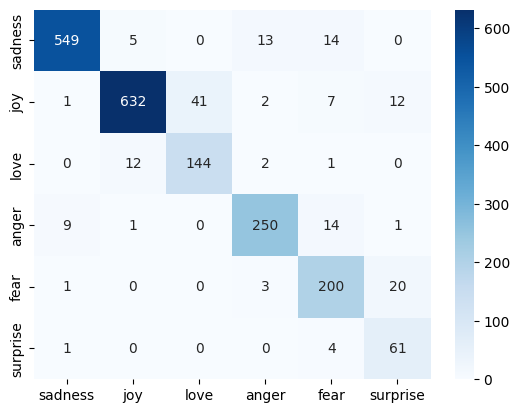

In [24]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequences),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)


###**9. Final Predictions**
Test the winning model on unseen sample sentences.

In [25]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


###**10. Save Model & Tokenizer**
Export trained model and tokenizer artifacts for API deployment.

In [26]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)